# CSE2530 Computational Intelligence
## Assignment 2: Artificial Neural Networks

<div style="background-color:#f1be3e">

_Fill in your group number **from Brightspace**, names, and student numbers._
    
|    Group   |           61          |
|------------|----------------------|
| Student A  |        XXXXXXX       |
| Student B  |        XXXXXXX       |
| Student C  |        XXXXXXX       |
| Student D  |        XXXXXXX       |

</div>

#### Imports

In [4]:
# You may only use numpy to implement your neural network
# You are not allowed to use scikit-learn, other than for Section 1.6.
# You are also not allowed to use Pytorch, Tensorflow, and similar machine learning frameworks.
# You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.

# Put all of your imports in this code block
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#### Loading the data

In [5]:
features = np.genfromtxt("../data/features.txt", delimiter=",") # 7854 samples of 10 features
targets = np.genfromtxt("../data/targets.txt", delimiter=",")   # 7854 target classes of the samples mentioned above
unknown = np.genfromtxt("../data/unknown.txt", delimiter=",")   # 784 samples of 10 features, with no lables available

## 1 Questions
### 1.2 Architecture
#### Question 1:

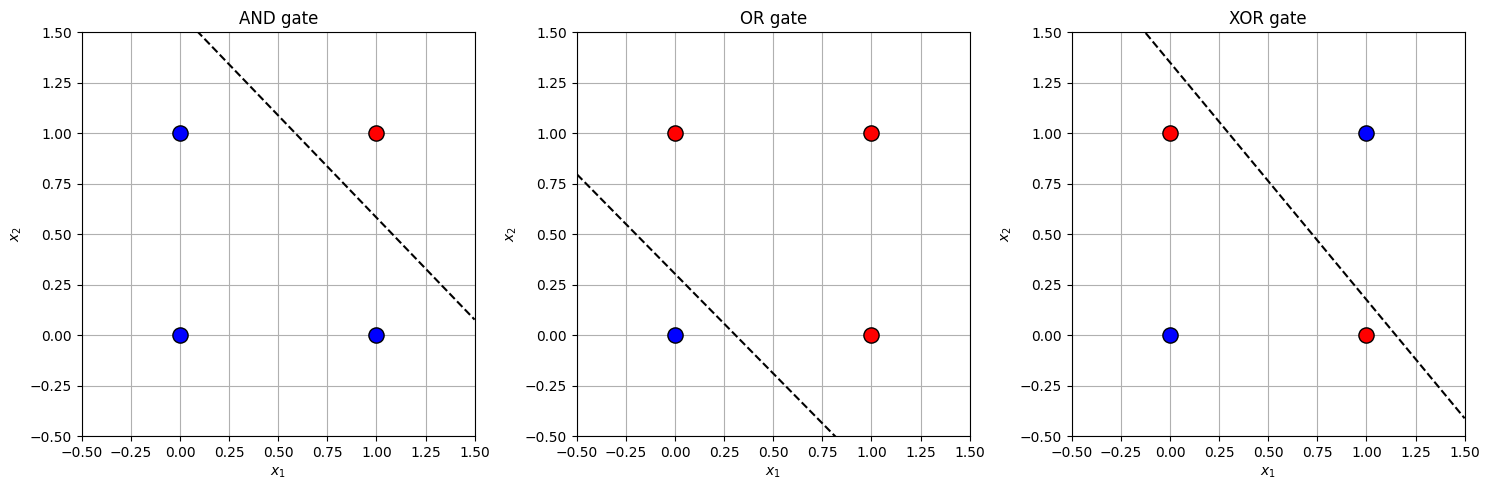

In [6]:
# Inputs
logic_gates = {
    "AND": {"x": [[0,0],[0,1],[1,0],[1,1]], "y": [0, 0, 0, 1]},
    "OR":  {"x": [[0,0],[0,1],[1,0],[1,1]], "y": [0, 1, 1, 1]},
    "XOR": {"x": [[0,0],[0,1],[1,0],[1,1]], "y": [0, 1, 1, 0]},
}

# Functions
def sigmoid(z):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-z))

def derivative_sigmoid(z):
    """Derivative of the sigmoid function."""
    return sigmoid(z) * (1 - sigmoid(z))

def forward_propagation(x, w, b):
    """Forward pass: computes pre-activation z and activation h = sigmoid(z)."""
    z = x @ w + b
    h = sigmoid(z)
    return z, h

def loss_function(h, true_y):
    """Mean squared error loss."""
    return np.sum((true_y - h) ** 2)

def backward_propagation(x, true_y, h, z):
    """Backward pass: computes gradients dw and db using the chain rule."""
    m = x.shape[0]
    dL_dz = -2 * (true_y - h) * derivative_sigmoid(z)
    dw = (x.T @ dL_dz) / m
    db = np.sum(dL_dz) / m
    return dw, db

def train_perceptron(x, true_y, epochs=1000, lr=0.1):
    """Trains a single perceptron with sigmoid activation using gradient descent.

    Returns: (w, b, loss_history)
    """
    x = np.array(x, dtype=float)
    true_y = np.array(true_y, dtype=float).reshape(-1, 1)

    w = np.random.randn(x.shape[1], 1)
    b = np.random.randn()
    loss_history = []

    for _ in range(epochs):
        z, h = forward_propagation(x, w, b)
        loss_history.append(loss_function(h, true_y))
        dw, db = backward_propagation(x, true_y, h, z)
        w -= lr * dw
        b -= lr * db

    return w, b, loss_history

# Train and plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, gate) in zip(axes, logic_gates.items()):
    X = np.array(gate["x"], dtype=float)
    y = np.array(gate["y"], dtype=float)
    w, b, losses = train_perceptron(gate["x"], gate["y"])

    for i in range(len(y)):
        color = "red" if y[i] == 1 else "blue"
        ax.scatter(X[i, 0], X[i, 1], c=color, s=120, edgecolors="k", zorder=3)

    w0, w1 = w.flatten()
    x_line = np.linspace(-0.5, 1.5, 200)
    if abs(w1) > 1e-10:
        ax.plot(x_line, -(w0 * x_line + b) / w1, "k--")
    else:
        ax.axvline(x=-b / w0, color="k", linestyle="--")

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(f"{name} gate")
    ax.grid(True)

plt.tight_layout()
plt.show()

#TODO: Explain what we did in questions 1, give correct and informative plots and add sensible discussion of all plots

<h4>Question 2: How many input neurons are needed in our classification task as described above? </h4>


The number of input neurons is fixed by the number of features in the input data. Since we have 10 features, we need 10 input neurons.

<h4>Question 3: How many output neurons do you require?</h4>

The number of output neurons is fixed by the task type. Since the task is to classify objects into multiple separate classes, one ouput neuron per class is required. Since there are 7 classes, the network will have 7 output neurons.

<h4>Question 4: How many hidden neurons and layers will your network have?

The number of hidden neurons and layers is determined by balancing the dataset complexity, available computational power and the risk of overfitting. Our dataset consists of 10 meaningful, human-designed features per sample and is of moderate size. Given this, a network with 1 hidden layer is a reasonable starting point, as a second layer would only be needed if the patterns are more complex or hierarchical.

There is no strict formula for choosing the numnber of neurons in a hidden layers, but common heuristics provide guidance. Two widely used rules are "the between the input and output size" rule and the 2/3 rule. The first suggests a number between the input and output size, in our case that would mean: (input + output)/2 = (10 + 7)/2 ≈ 8 neurons. The 2/3 rule gives (2/3) * input + output = (2/3) * 10 + 7 ≈ 14. These values are usually enough to learn simple patterns, but may not capture more subtle feature interactions.

To provide extra capacity while maintaining computational efficiency, we decided to roughly double the heuristic values, giving 30 neurons. Following standard practice of using powers of 2, we rounded this to 32 neurons.

During experimentation, if the network underfits (fails to learn the patterns), the number of neurons can be increased, and if it overfits (memorises the training data), they can be reduced. A second hidden layer can be added if the network struggles to capture more complex or hierarchical relationships.

<h4>Question 5: Which activation function(s) will you use?</h4>

The neural network will use Leaky Rectified Linear Unit (RELU) for the hidden layer and Softmax for the output layer.

ReLU is effective, because it enables fast learning, avoids vanishing gradients and efficiently handles the 10 input features. Leaky ReLU is a variant of ReLU that allows a small slope for negative inputs, preventing dead neurons (neurons that output 0 for all inputs), which can otherwise slow down training. 

The Softmax function converts raw outputs into probabilities that sum into 1, ,making it ideal for multiclass classifiction, as required in this assignment. It is similar to the Sigmoid function used for binary classification, but generalised for multiple classes. Softmax is also smooth and differentiable everywhere, which is necessary for backpropagation.

<h4>Question 6: Give a schematic diagram of your complete network based on your previous answers</h4>

#TODO

### 1.3 Training

When coding a neural network from scratch, it helps to think of a layer as an individual component that can be easily combined with other layers. To help you create a modular implementation of a neural network, we provide you with a template for the implementation along with some explanations.

**Note that using the template below is not mandatory. You may choose to modify this template or implement your own version of the neural network altogether. If the latter, please remove our template from the notebook and ensure that it instead includes a complete, fully functional implementation of your own.**

**Linear (fully connected) layer**

A linear or fully connected layer maps the input data to an output by performing a linear transformation, where each input neuron is connected to every output neuron. The forward pass of a linear layer is computed as $y = wx + b$, where $w$ and $b$ are trainable parameters. The gradients of the loss with respect to $w$ and $b$ are defined using the chain rule:

$$\frac{\partial \mathcal{L}}{\partial w}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial w}, \quad \frac{\partial \mathcal{L}}{\partial b}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial b}, $$

where $\frac{\partial \mathcal{L}}{\partial y}$ is the upstream gradient i.e., the gradient flowing from deeper layers into the current layer, and the other two terms are the local gradients:

$$
\frac{\partial y}{\partial w}=x, \quad \frac{\partial y}{\partial b}=1.
$$

Since $x$ is needed to compute the gradients, we can store (cache) its value during the forward pass. Finally, we need to return a downstream gradient so that more shallow layers can use it as their upstream gradient. The downstream gradient of a layer is simply its upstream gradient multiplied by the local gradient of its ouput with respect to its input:

$$
\frac{\partial \mathcal{L}}{\partial x}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial x}
$$

**Note.** Be aware of how you multiply the arrays, it might be useful to print the shapes of each array and to think about the desired shape of the output.  

In [7]:
class Linear:
    def __init__(self, in_features, out_features):
        """ Randomly initialize the weights and biases.

        Args:
            in_features: number of input features.
            out_features: number of output features.
        """

        self.weight = ...
        self.bias = ...

        self.cache = None
        # For storing the gradients w.r.t. the weight and the bias
        self.weight_grad = None
        self.bias_grad = None

    def forward(self, x):
        """ Perform the forward pass of a linear layer. 
        Store (cache) the input so it can be used in the backward pass.

        Args:
            x: input of a linear layer.

        Returns: 
            y: output of a linear layer. 
        """

        pass
    
    def backward(self, dupstream):
        """ Perform the backward pass of a linear layer.  

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
       
        pass

**Activation functions**

You also need to implement an activation function suitable for the task at hand.

Think about how to perform the backward pass i.e., what is the local gradient and what the downstream gradient should be. Do not forget to take the upstream gradient into account.

In [8]:
class Activation:
    def __init__(self):
        self.cache = None
    
    def forward(self, x):
        """ Perform a forward pass of your activation function.
        Store (cache) the output so it can be used in the backward pass.

        Args:
            x: input to the activation function. 

        Returns:
            y: output of the activation function.
        """

        pass
    
    def backward(self, dupstream): 
        """ Perform a backward pass of the activation function. 
        Make sure you do not modify the original dupstream.

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        
        pass

**Network** 

Now that you have implemented a `Linear` layer and an activation function, you can combine them in different ways and have the `Network` class perform forward and backward passes through all layer of the network in the specified order.

Additionally, you should make the `Network` class update all the trainable parameters of the network in `optimizer_step`.

In [9]:
class Network:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, x):
        """ Perform a forward pass over the entire network.

        Args:
            x: input data. 

        Returns:
            y: predictions.
        """
        
        pass
    
    def backward(self, dupstream):
        """ Perform a backward pass over the entire network.

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        
        pass
    
    def optimizer_step(self, lr):
        """ Update the weight and bias parameters of each layer.

        Args:
            lr: learning rate.
        """
        
        pass

**Loss function**

You also need to implement a loss function that will measure how well your neural network performs at the task.

In [10]:
def Loss(y_true, y_pred):
    """ Computes the value of the loss function and its gradient.  

    Args:
        y_true: ground truth labels.
        y_pred: predicted labels.

    Returns:
        loss: value of the loss. 
        grad: gradient of loss with respect to the predictions. 
    """

    pass

**Training loop**

Finally, define a training loop in which for each optimizer step you:

1. Obtain the predictions by performing a forward pass of the network;

2. Compute the loss and its gradient by comparing the predictions with the ground truth according to the selected criterion;

3. Perform a backward pass of the network;

4. Update all parameters of the network i.e, take an optimizer step.

In [11]:
def train(net, inputs, labels, criterion, lr):
    """Trains the neural network.

    Args:
        net: network or model. 
        inputs: input data.
        labels: labels. 
        criterion: loss function.
        lr: learning rate.

    Returns:
        losses: a list containing the loss at every optimizer step. 
        accuracies: a list containing the accuracy at every optimizer step. 
    """
    
    pass

#### Question 7

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 8

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 9

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 10

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.4 Optimization

#### Question 11

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 12

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.5 Evaluation

#### Question 13

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 14

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 15

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.6 Scikit-learn

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 17

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.7 Reflection

#### Question 18

<div style="background-color:#f1be3e">

_Write your answer here._

</div>

#### Question 19

<div style="background-color:#f1be3e">

_Write your answer here._

</div>

### 1.8 Pen and paper

#### Question 20

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

</div>

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

</div>

### 1.9 Division of work

#### Question 22

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

</div>

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**

</div>